In [5]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=50)

In [6]:
faces.data.shape

(1560, 2914)

In [7]:
faces.images[0].shape

(62, 47)

In [8]:
62*47

2914

In [9]:
faces.target_names

array(['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
       'Gerhard Schroeder', 'Hugo Chavez', 'Jacques Chirac',
       'Jean Chretien', 'John Ashcroft', 'Junichiro Koizumi',
       'Serena Williams', 'Tony Blair'], dtype='<U17')

In [10]:
faces.target_names.size

12

In [11]:
faces.target

array([11,  4,  2, ...,  3, 11,  5], shape=(1560,))

In [12]:
faces.target_names[4]

np.str_('Gerhard Schroeder')

In [2]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=50)

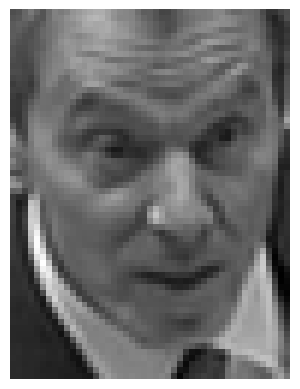

In [3]:
import matplotlib.pyplot as plt

plt.imshow(faces.images[0], cmap="gray")
plt.axis("off")
plt.show()


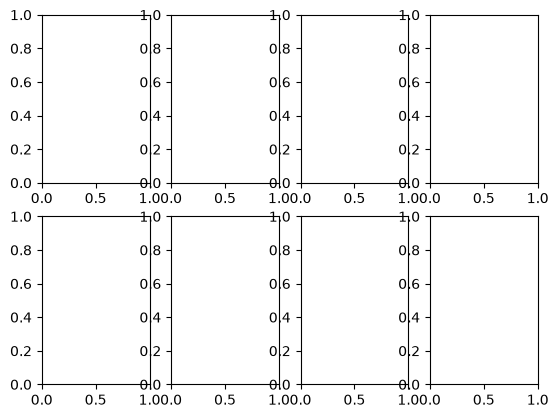

In [4]:
fig , ax = plt.subplots(2,4)

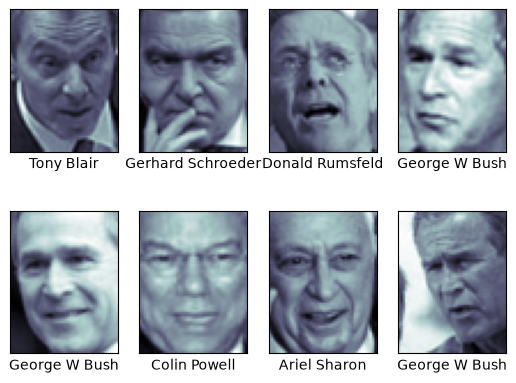

In [6]:
fig , ax = plt.subplots(2,4)
for idx,axidx in enumerate(ax.flat):
    axidx.imshow(faces.images[idx], cmap="bone")
    axidx.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[idx]])

In [7]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

In [8]:
pcaModel = PCA(n_components=150, whiten=True)
svmModel = SVC(kernel="rbf", class_weight="balanced")
mdl = make_pipeline(pcaModel, svmModel)

In [14]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(faces.data, faces.target, test_size=0.2, random_state=42)

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc___C':[1,5,10,50], 'svc__gamma':[0.0001,0.0005,0.001,0.005]}
grid = GridSearchCV(mdl, param_grid)

In [18]:
param_grid = {'svc__C': [1, 5, 10, 50], 'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(mdl, param_grid)
grid.fit(Xtrain, Ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': [1, 5, ...], 'svc__gamma': [0.0001, 0.0005, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of informa

In [19]:
print(grid.best_params_)

{'svc__C': 1, 'svc__gamma': 0.005}


In [20]:
mdl = grid.best_estimator_


In [21]:
y_pred = mdl.predict(Xtest)

In [23]:
Ytest

array([ 3,  1,  3, 11,  1,  3,  5,  2,  4,  2,  5,  2, 11,  0,  3,  3,  1,
        1,  0,  5,  3,  3,  3, 10, 11,  3,  3,  8,  1,  1,  2,  6,  3,  2,
        3,  3,  9,  3, 10,  3,  0,  1,  1, 11,  5,  3,  3,  3,  3,  3,  1,
        3,  8,  1,  3,  4,  1,  1,  8,  2,  7,  3,  3,  9,  4,  1,  2,  2,
        3,  3,  3, 11,  5,  3,  1,  3,  3,  8,  4,  2,  4,  3,  2,  4,  1,
       11,  1, 11, 11,  1,  3,  3,  1, 11, 11, 11,  2,  4,  3,  3,  4,  5,
        2,  3,  3,  3,  9,  2,  4,  3,  1,  0,  3,  3,  3,  3,  1, 10,  4,
        4,  1,  7,  0,  1, 11,  3, 10, 10,  3,  3,  1,  6,  7, 11,  7, 11,
        1, 11,  3,  5,  3,  3,  6,  3,  1,  7,  1,  9,  5,  3,  5,  7,  4,
        3,  8,  1,  3,  2, 11,  1,  9,  3,  1,  3, 11,  1,  3, 11,  3,  2,
        3,  3,  3, 11,  3,  1, 11,  8,  1,  3,  2,  3,  3,  1,  8,  0, 11,
       11,  1,  5,  7,  3,  3, 11,  1,  1,  4,  8,  3,  1,  3,  3,  3,  3,
        2,  3,  2,  3,  2,  3, 11,  2,  3,  3,  3, 11, 11,  5,  5,  4,  3,
        3,  0,  3,  3, 11

In [24]:
y_pred

array([ 3,  1,  3, 11,  1,  3,  5,  2,  4,  2,  3,  4, 11,  0,  0,  3,  1,
        1,  0,  5,  3,  3,  1,  5, 11,  3,  3,  8,  1,  1,  2,  6,  3,  2,
        3,  3,  3,  4, 10,  3,  1,  1,  1, 11,  1,  3,  3,  3,  3,  3,  1,
        3,  8,  1,  3,  4,  1,  1,  8,  2,  7,  3,  3,  9,  4,  1,  2,  2,
        2,  0,  3, 11, 11,  3,  1,  3,  1,  8,  4,  2,  4,  3,  2,  2,  0,
       11,  1, 11, 11,  1,  3,  3,  1, 11, 11, 11,  2,  4,  1,  3,  3,  5,
        2,  3,  3,  3,  3,  1,  4,  3,  4,  0,  3,  3,  3,  3,  1, 10,  2,
        4,  1,  7,  0,  1,  3,  3,  1, 10,  3, 11,  1,  3,  7, 11,  7, 11,
        1, 11,  3,  5,  3,  3,  3,  2,  1,  3,  1,  9,  5,  3,  3,  7,  4,
        3,  8,  1,  3,  1, 11,  1,  9,  3,  1,  1, 11,  1,  6, 11,  3,  2,
        3,  3,  3,  4,  3,  1, 11,  8,  1,  3,  2,  1,  3,  1,  8,  0,  4,
       11,  1,  5,  7,  3,  3,  3,  1,  1,  4,  8,  3,  1,  3,  3,  3,  3,
        2,  3,  2,  3,  2,  8, 11,  2,  3,  3,  3, 11, 11,  5,  5,  4,  3,
        3,  0,  3,  3, 11

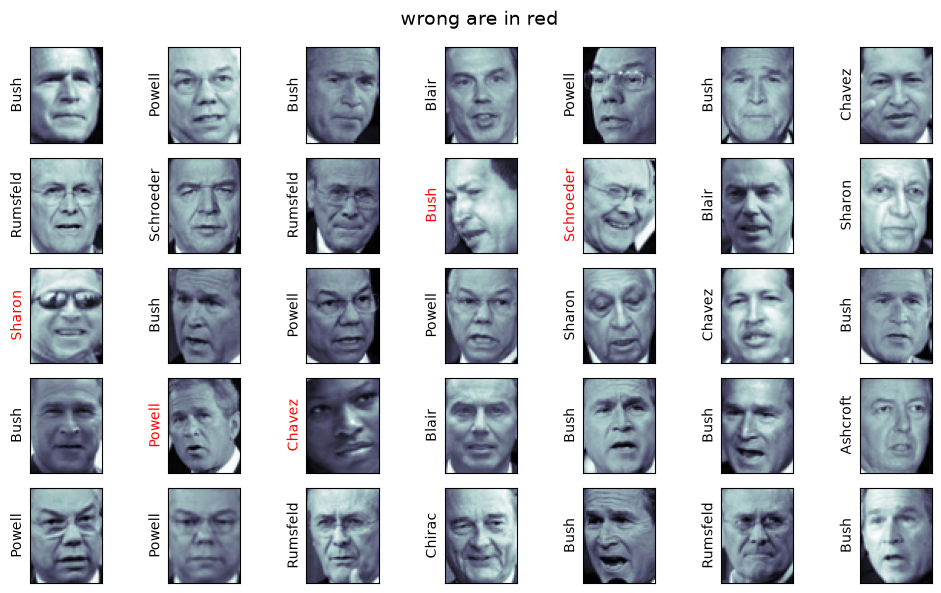

In [31]:
fig, ax = plt.subplots(5,7, figsize=(10, 6))

for idx, axidx in enumerate(ax.flat):

    axidx.imshow(Xtest[idx].reshape(62, 47), cmap="bone")

    axidx.set(xticks=[], yticks=[])

    axidx.set_ylabel(
        faces.target_names[y_pred[idx]].split()[-1],
        color="black" if y_pred[idx] == Ytest[idx] else "red"
    )

fig.suptitle("wrong are in red", size=14)

plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report

In [35]:
print(classification_report(Ytest, y_pred, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.67      0.73      0.70        11
     Colin Powell       0.76      0.91      0.83        55
  Donald Rumsfeld       0.81      0.84      0.82        25
    George W Bush       0.89      0.87      0.88       107
Gerhard Schroeder       0.76      0.76      0.76        21
      Hugo Chavez       0.90      0.64      0.75        14
   Jacques Chirac       0.80      0.57      0.67         7
    Jean Chretien       1.00      0.92      0.96        12
    John Ashcroft       0.92      0.92      0.92        12
Junichiro Koizumi       1.00      0.75      0.86         8
  Serena Williams       0.83      0.71      0.77         7
       Tony Blair       0.88      0.85      0.86        33

         accuracy                           0.84       312
        macro avg       0.85      0.79      0.81       312
     weighted avg       0.85      0.84      0.84       312



In [48]:
import sys
print(sys.executable)

c:\Users\Aditya Singh\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [49]:
import sys
!{sys.executable} -m pip install seaborn


'c:\Users\Aditya' is not recognized as an internal or external command,
operable program or batch file.


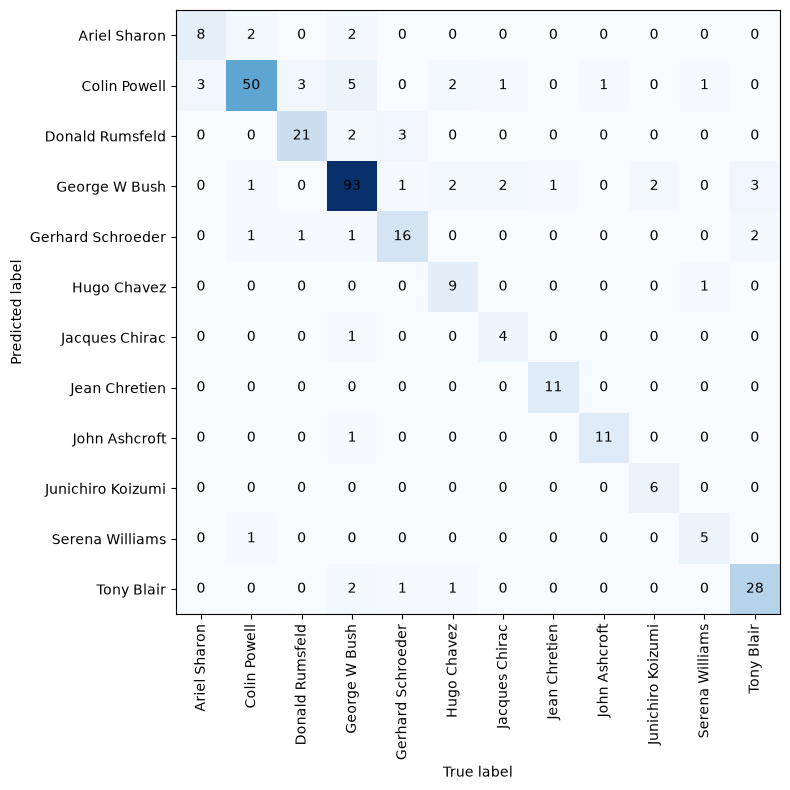

In [55]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
mat = confusion_matrix(Ytest, y_pred)

# Plot
plt.figure(figsize=(10, 8))

plt.imshow(mat.T, interpolation='nearest', cmap=plt.cm.Blues)

# Add numbers inside each cell
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        plt.text(i, j, mat[i, j],
                 ha="center",
                 va="center")

# Labels
plt.xticks(
    range(len(faces.target_names)),
    faces.target_names,
    rotation=90
)

plt.yticks(
    range(len(faces.target_names)),
    faces.target_names
)

plt.xlabel("True label")
plt.ylabel("Predicted label")

plt.tight_layout()
plt.show()